# Manual Anomaly Injection on Stable Sales

Since the original dataset contains no labeled anomalies, synthetic ground truth is constructed manually for model training and evaluation. The notebook identifies the most stable product–day combinations in August 2025 — periods of sustained high sales with continuous stock availability during operating hours (07:00–22:00) — and injects anomalies by zeroing out sales at selected hours within those periods.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data_v1.csv')

In [3]:
df['date'] = pd.to_datetime(df['date'])

## 2. Filtering: August Data and Established Products

The analysis is restricted to August 2025. Products whose first recorded sale falls within August are excluded — their sales baseline cannot be reliably established from the available history, making them unsuitable as anomaly injection targets.

In [4]:
df_aug = df[df['date'].dt.month == 8].copy()

first_sales = df.groupby('product').apply(
    lambda x: x[x['sales'] > 0]['date'].min()
).reset_index(name='first_sale_date')

august_first_products = first_sales[
    first_sales['first_sale_date'].dt.month == 8
]['product']

df_aug = df_aug[~df_aug['product'].isin(august_first_products)]

## 3. Identifying Stable Product–Day Combinations

A combination (product, day) is considered **stable** if:
- stock is continuously positive during operating hours (07:00–22:00),
- sales exceed 3 units in at least 6 hours of that window.

Stability across consecutive days is measured as the maximum spread between average daily sales on the target day, the previous day, and the same day one week prior. Combinations with missing reference days are excluded.

The top 50 most temporally stable combinations are selected for anomaly injection.

In [5]:
df['day'] = df['date'].dt.date
df_aug = df[df['date'].dt.month == 8].copy()
df_aug['day'] = df_aug['date'].dt.date
df_aug['hour'] = df_aug['date'].dt.hour

df_work = df_aug[(df_aug['hour'] >= 7) & (df_aug['hour'] <= 22)]

full_stock = (
    df_work.groupby(['day', 'product'])['stocks']
    .apply(lambda x: (x > 0).all())
    .reset_index(name='has_full_stock')
)
full_stock = full_stock[full_stock['has_full_stock']]

df_work = df_work.merge(full_stock[['day', 'product']], on=['day', 'product'])

stable = (
    df_work[df_work['sales'] > 3]
    .groupby(['day', 'product'])
    .size()
    .reset_index(name='high_sales_hours')
)
stable = stable[stable['high_sales_hours'] >= 6].sort_values('high_sales_hours', ascending=False)

top100 = stable.head(100).reset_index(drop=True)

daily_avg = df.groupby(['day', 'product'])['sales'].mean().reset_index()
daily_avg_aug = df_aug.groupby(['day', 'product'])['sales'].mean().reset_index()

info = []
for idx, row in top100.iterrows():
    day = row['day']
    prod = row['product']

    avg_today = daily_avg_aug[
        (daily_avg_aug['day'] == day) & (daily_avg_aug['product'] == prod)
    ]['sales'].values
    avg_yest = daily_avg[
        (daily_avg['day'] == day - pd.Timedelta(days=1)) & (daily_avg['product'] == prod)
    ]['sales'].values
    avg_week = daily_avg[
        (daily_avg['day'] == day - pd.Timedelta(days=7)) & (daily_avg['product'] == prod)
    ]['sales'].values

    t = avg_today[0] if len(avg_today) > 0 else None
    y = avg_yest[0] if len(avg_yest) > 0 else None
    w = avg_week[0] if len(avg_week) > 0 else None

    diff = max(t, y, w) - min(t, y, w) if (t and y and w) else 999

    info.append({
        'No': idx + 1,
        'Date': str(day),
        'Product': str(prod),
        'Today avg': round(t, 1) if t is not None else 'NaN',
        'Yesterday avg': round(y, 1) if y is not None else 'NaN',
        'Week ago avg': round(w, 1) if w is not None else 'NaN',
        'Spread (max-min)': round(diff, 1)
    })

info_df = pd.DataFrame(info)
info_df = info_df[
    (info_df['Today avg'] != 'NaN') &
    (info_df['Yesterday avg'] != 'NaN') &
    (info_df['Week ago avg'] != 'NaN') &
    (info_df['Spread (max-min)'] < 900)
].copy()

info_df = info_df.sort_values('Spread (max-min)').reset_index(drop=True)

print(f"Stable combinations after filtering: {len(info_df)}\n")
print(info_df.to_string(index=False))

Stable combinations after filtering: 96

 No       Date         Product  Today avg Yesterday avg Week ago avg  Spread (max-min)
 41 2025-08-22 1784610E0075437        3.5           3.6          3.6               0.1
 65 2025-08-30 1784610E0074360        3.0           3.3          3.3               0.3
 81 2025-08-13 1784610E0074356        4.1           4.1          4.5               0.4
 68 2025-08-10 17846D000004968        3.7           3.3          3.5               0.4
 22 2025-08-20 17846DI00081186        4.2           4.7          4.9               0.6
 97 2025-08-02 1784610E0074356        4.0           3.9          4.5               0.6
 56 2025-08-09 1784610E0074360        4.7           5.3          4.9               0.6
 74 2025-08-23 1784610E0074356        4.0           3.6          3.2               0.7
 69 2025-08-04 178461100071922        4.0           3.3          4.1               0.8
 95 2025-08-05  17846ЦТ0036199        3.0           2.7          2.3               0.8
 8

## 4. Top 50 Stable Combinations - Hourly Sales Before Injection

Each subplot shows hourly sales (blue bars) and stock level (orange line) for one product–day combination during operating hours. Only the 50 most temporally stable combinations are shown.

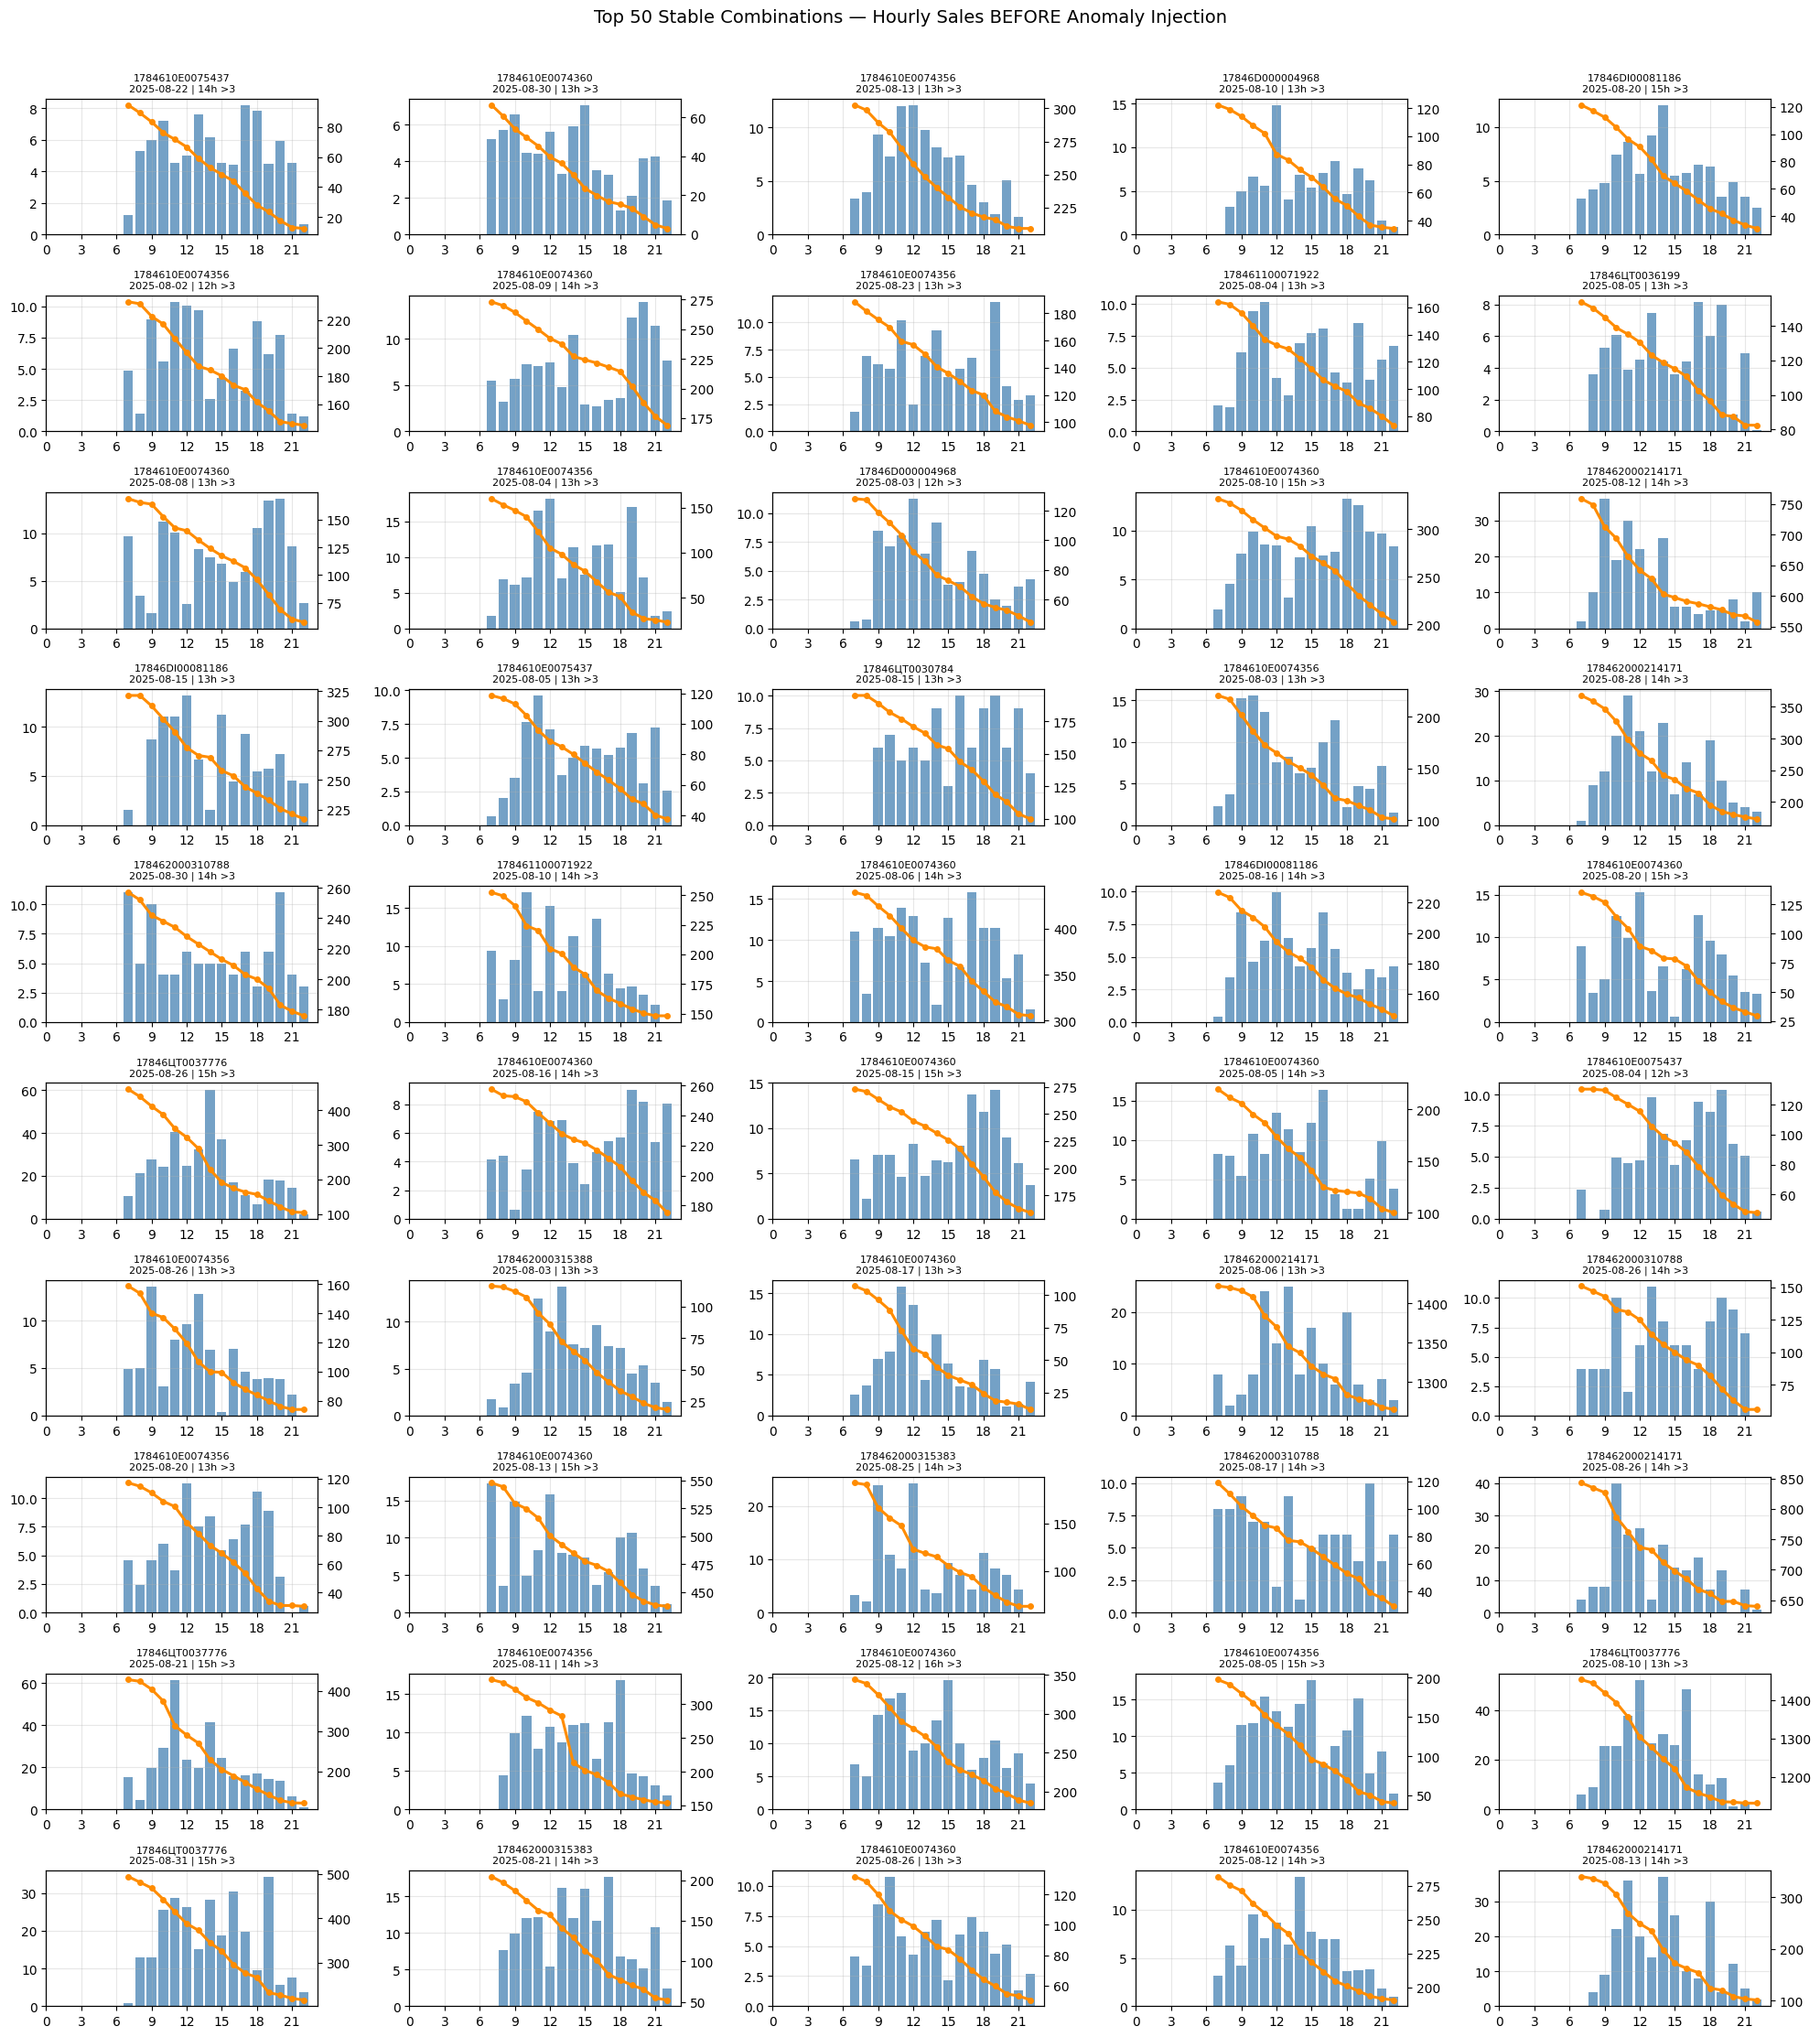

In [6]:
top50_for_graphs = info_df.head(50)

n_cols = 5
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 22))
axes = axes.flatten()

for idx, row in top50_for_graphs.iterrows():
    prod = row['Product']
    date = pd.to_datetime(row['Date']).date()

    mask = (df_work['product'] == prod) & (df_work['day'] == date)
    day_data = df_work[mask].copy()

    hourly = day_data.groupby('hour').agg(
        sales=('sales', 'sum'),
        stocks=('stocks', 'last')
    ).reset_index()

    ax = axes[idx]
    ax.bar(hourly['hour'], hourly['sales'], color='steelblue', alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(hourly['hour'], hourly['stocks'], color='darkorange', linewidth=2.2, marker='o', markersize=4)

    high_hrs = top100[
        (top100['product'] == prod) & (top100['day'] == date)
    ]['high_sales_hours'].values[0]

    ax.set_title(f"{prod}\n{date} | {int(high_hrs)}h >3", fontsize=8)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.3)

plt.suptitle("Top 50 Stable Combinations — Hourly Sales BEFORE Anomaly Injection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Anomaly Injection

Sales are zeroed at specific (product, date, hour) coordinates selected from the top 50 stable combinations. Each zeroed record represents a synthetic anomaly — an unexpected sales drop during a period when normal activity would be expected given full stock availability.

The list below defines the injection targets.

In [7]:
rows_to_zero_list = [
    ("22.08.2025", "1784610E0075437", 18),
    ("30.08.2025", "1784610E0074360", 15),
    ("13.08.2025", "1784610E0074356", 12),
    ("10.08.2025", "17846D000004968", 17),
    ("20.08.2025", "17846DI00081186", 11),
    ("02.08.2025", "1784610E0074356", 13),
    ("09.08.2025", "1784610E0074360", 20),
    ("23.08.2025", "1784610E0074356", 14),
    ("04.08.2025", "178461100071922", 10),
    ("05.08.2025", "17846ЦТ0036199", 18),
    ("08.08.2025", "1784610E0074360", 21),
    ("04.08.2025", "1784610E0074356", 11),
    ("03.08.2025", "17846D000004968", 10),
    ("10.08.2025", "1784610E0074360", 11),
    ("12.08.2025", "178462000214171", 14),
    ("15.08.2025", "17846DI00081186", 11),
    ("05.08.2025", "1784610E0075437", 14),
    ("15.08.2025", "17846ЦТ0030784", 16),
    ("03.08.2025", "1784610E0074356", 13),
    ("28.08.2025", "178462000214171", 17),
    ("30.08.2025", "178462000310788", 9),
    ("10.08.2025", "178461100071922", 12),
    ("06.08.2025", "1784610E0074360", 17),
    ("16.08.2025", "17846DI00081186", 19),
    ("20.08.2025", "1784610E0074360", 12),
    ("26.08.2025", "17846ЦТ0037776", 22),
    ("16.08.2025", "1784610E0074360", 7),
    ("15.08.2025", "1784610E0074360", 9),
    ("15.08.2025", "1784610E0074360", 22),
    ("05.08.2025", "1784610E0074360", 19),
    ("05.08.2025", "1784610E0074360", 22),
    ("04.08.2025", "1784610E0075437", 10),
    ("26.08.2025", "1784610E0074356", 8),
    ("03.08.2025", "178462000315388", 9),
    ("17.08.2025", "1784610E0074360", 8),
    ("17.08.2025", "1784610E0074360", 11),
    ("17.08.2025", "1784610E0074360", 19),
    ("06.08.2025", "178462000214171", 7),
    ("06.08.2025", "178462000214171", 18),
    ("26.08.2025", "178462000310788", 7),
    ("26.08.2025", "178462000310788", 18),
    ("20.08.2025", "1784610E0074356", 9),
    ("13.08.2025", "1784610E0074360", 7),
    ("13.08.2025", "1784610E0074360", 22),
    ("25.08.2025", "178462000315383", 8),
    ("25.08.2025", "178462000315383", 12),
    ("17.08.2025", "178462000310788", 13),
    ("17.08.2025", "178462000310788", 14),
    ("26.08.2025", "178462000214171", 8),
    ("21.08.2025", "17846ЦТ0037776", 9),
    ("21.08.2025", "17846ЦТ0037776", 22),
    ("11.08.2025", "1784610E0074356", 22),
    ("12.08.2025", "1784610E0074360", 21),
    ("05.08.2025", "1784610E0074356", 8),
    ("05.08.2025", "1784610E0074356", 11),
    ("10.08.2025", "17846ЦТ0037776", 8),
    ("10.08.2025", "17846ЦТ0037776", 19),
    ("31.08.2025", "17846ЦТ0037776", 8),
    ("31.08.2025", "17846ЦТ0037776", 22),
    ("21.08.2025", "178462000315383", 21),
    ("21.08.2025", "178462000315383", 22),
    ("26.08.2025", "1784610E0074360", 22),
    ("12.08.2025", "1784610E0074356", 8),
    ("12.08.2025", "1784610E0074356", 21),
    ("13.08.2025", "178462000214171", 18),
]

existing_products = set(df_aug['product'].astype(str).unique())
rows_to_zero_list = [r for r in rows_to_zero_list if r[1] in existing_products]

target_df = pd.DataFrame(rows_to_zero_list, columns=['date_str', 'product', 'hour'])
target_df['date_only'] = pd.to_datetime(target_df['date_str'], format='%d.%m.%Y').dt.date
target_df = target_df.drop(columns=['date_str'])

if 'hour' not in df_aug.columns:
    df_aug['hour'] = df_aug['date'].dt.hour
df_aug['date_only'] = df_aug['date'].dt.date

df_aug['_key'] = (
    df_aug['date_only'].astype(str) + '|' +
    df_aug['product'].astype(str) + '|' +
    df_aug['hour'].astype(str)
)
target_df['_key'] = (
    target_df['date_only'].astype(str) + '|' +
    target_df['product'].astype(str) + '|' +
    target_df['hour'].astype(str)
)

mask = df_aug['_key'].isin(set(target_df['_key']))
zeroed_rows = df_aug.loc[mask].copy()
df_aug.loc[mask, 'sales'] = 0
df_aug = df_aug.drop(columns=['date_only', '_key'])

print(f"Zeroed rows: {len(zeroed_rows)}")
print("Dataset is ready for model evaluation.")

Zeroed rows: 65
Dataset is ready for model evaluation.


## 6. Top 50 Stable Combinations — Hourly Sales After Injection

The same 50 combinations are plotted after zeroing. Red bars mark injected anomalies (hours where sales were set to zero). Orange line shows stock level — confirming that stock was available at the time of the anomaly.

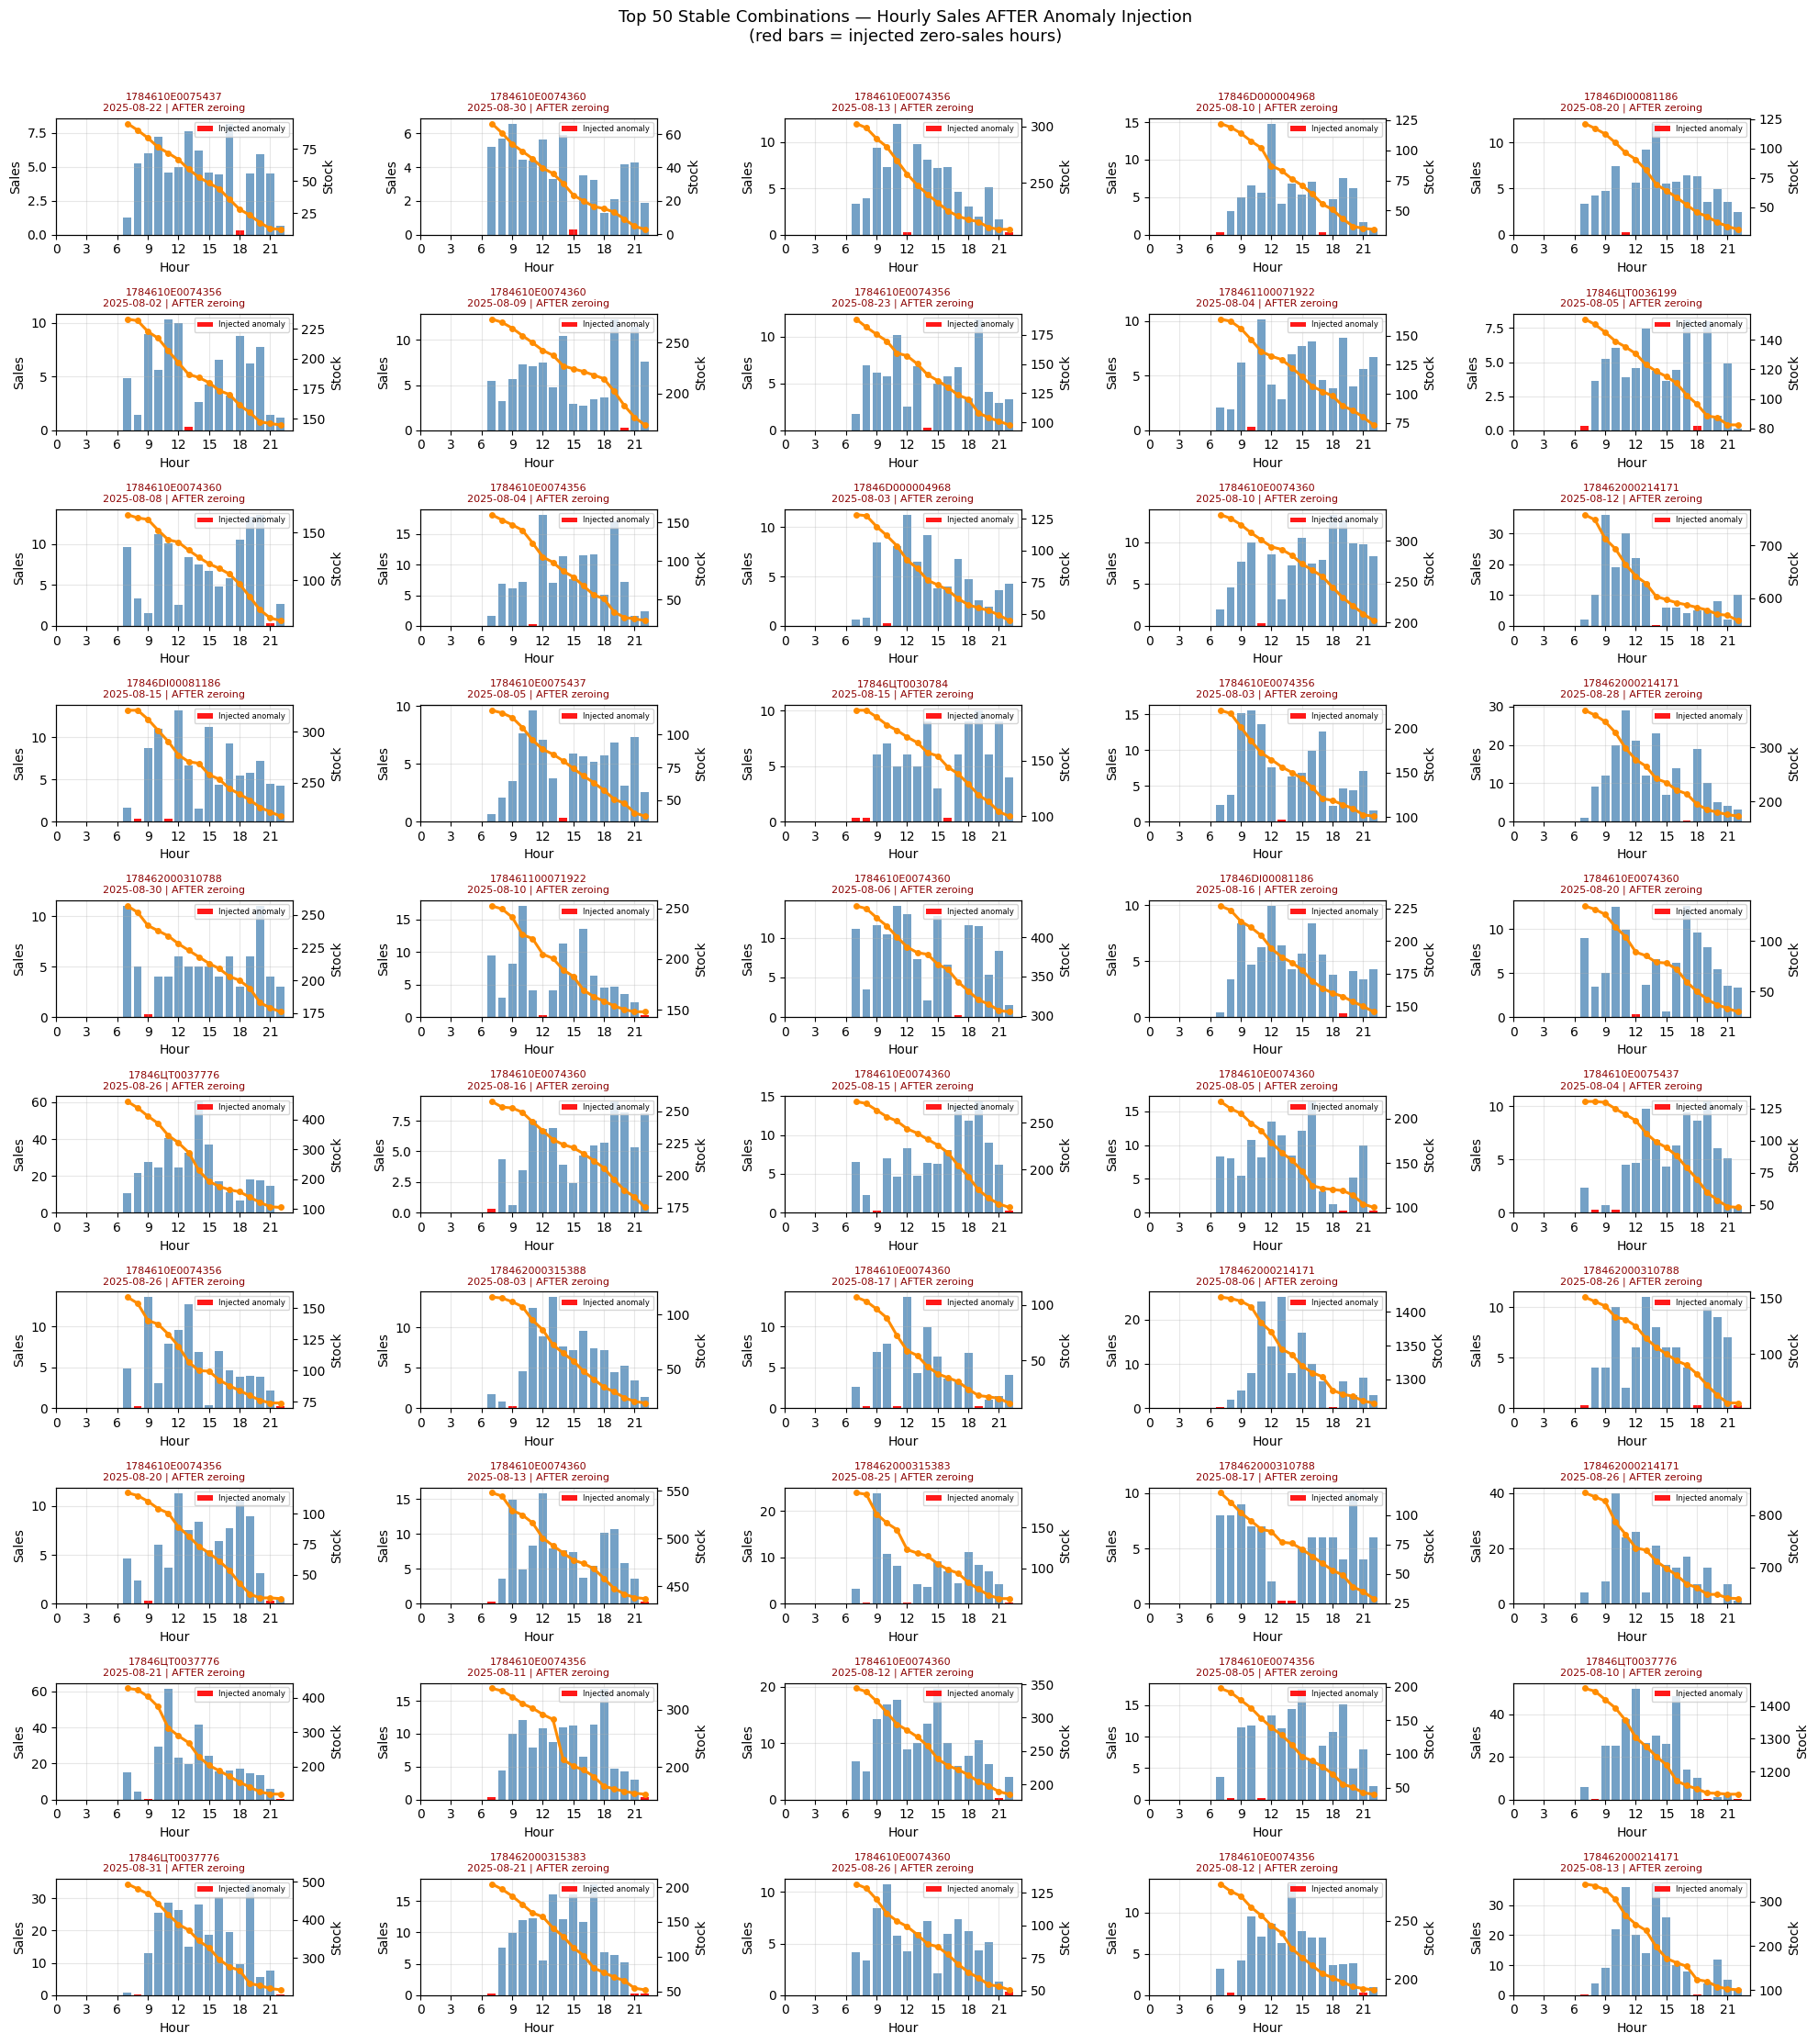

In [8]:
if 'hour' not in df_aug.columns:
    df_aug['hour'] = df_aug['date'].dt.hour
df_aug['day'] = df_aug['date'].dt.date

df_work_post = df_aug[(df_aug['hour'] >= 7) & (df_aug['hour'] <= 22)].copy()

full_stock_post = (
    df_work_post.groupby(['day', 'product'])['stocks']
    .apply(lambda x: (x > 0).all())
    .reset_index(name='has_full_stock')
)
full_stock_post = full_stock_post[full_stock_post['has_full_stock']]
df_work_post = df_work_post.merge(
    full_stock_post[['day', 'product']], on=['day', 'product'], how='inner'
)

n_cols = 5
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 22))
axes = axes.flatten()

for plot_idx, (_, row) in enumerate(top50_for_graphs.iterrows()):
    prod = row['Product']
    date = pd.to_datetime(row['Date']).date()

    mask = (df_work_post['product'] == prod) & (df_work_post['day'] == date)
    day_data = df_work_post[mask].copy()

    if len(day_data) == 0:
        continue

    hourly = day_data.groupby('hour').agg(
        sales=('sales', 'sum'),
        stocks=('stocks', 'last')
    ).reset_index()

    zero_hours = hourly[hourly['sales'] == 0]['hour'].tolist()

    ax = axes[plot_idx]
    ax.bar(hourly['hour'], hourly['sales'], color='steelblue', alpha=0.75)
    for h in zero_hours:
        ax.bar(h, 0.3, color='red', alpha=0.9, width=0.8,
               label='Injected anomaly' if h == zero_hours[0] else "")

    ax2 = ax.twinx()
    ax2.plot(hourly['hour'], hourly['stocks'], color='darkorange', linewidth=2.2, marker='o', markersize=4)

    ax.set_title(
        f"{prod}\n{date} | AFTER zeroing",
        fontsize=8,
        color='darkred' if zero_hours else 'black'
    )
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel('Hour')
    ax.set_ylabel('Sales')
    ax2.set_ylabel('Stock')
    ax.grid(True, alpha=0.3)

    if zero_hours:
        ax.legend(loc='upper right', fontsize=6)

plt.suptitle(
    "Top 50 Stable Combinations — Hourly Sales AFTER Anomaly Injection\n(red bars = injected zero-sales hours)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [9]:
zeroed_rows.to_csv('df_aug_final_check_rows.csv', index=False)
df_aug.to_csv('df_aug_final.csv', index=False)

## Summary

| Step | Description |
|------|-------------|
| Filtering | August 2025 data; products with sales history prior to August only |
| Stability criteria | Full stock 07:00–22:00; sales > 3 units in ≥ 6 hours |
| Temporal stability | Low spread between today / yesterday / one week ago averages |
| Injection targets | 50 most stable product–day combinations |
| Anomaly type | Sales zeroed at specific hours despite positive stock |
| Output | `df_aug` — labeled dataset ready for model evaluation |